# OPAN-6609 Final Project
## Saxa 3
### 4/26/2026
#### Anya, Jackie, Justus, Rick, Theo
---

In [7]:
pip install nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.6 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 6.2 MB/s  0:00:00

   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   --------

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt


#### Q1 - Ingest and process the customer reviews dataset.

In [9]:
# Read in CSV
df = pd.read_csv("hotel_final.csv")
df.head(10)

,Unnamed: 0,reviewID,reviewContent,rating,usefulCount,coolCount,funnyCount
0,2982,-ZkzDLAp-6LSdek-nU,My husband took me to stay the night for a fun...,4,0,0,0
1,2983,9yStfyRS5CISu-May43dmA,"stayed at the property over the weekend, got a...",3,0,0,0
2,2984,Wf-7bJszS2n6REXGbrwK2w,"Overall, I think I'm less and less a fan of th...",3,0,0,0
3,2985,ZLe,I'd like to make a confession. I don't really ...,3,21,11,16
4,2986,vURf9AGmThDrRC9TVcQrdw,The good: the view; location The bad: servic...,1,0,0,0
5,2987,NwZ6u5xqXJGfPNHeKFJVhQ,"Great service, beautiful hotel and rooms! The ...",4,0,0,0
6,2988,E1j78xcwMYnymNRlfse-EQ,You cannot go wrong with a W Hotel. It is styl...,4,2,0,0
7,2989,kv-eRN6LOX2-oUfnEMd0uA,Pro's Water views Navy Pier Views Rides via Ac...,3,1,1,2
8,2990,40gDUe2eVedqCXqDS8cnmA,Amazing views and location. The room was nice...,4,0,0,0
9,2991,C2,Not my fave W:-( Lobby is just OK. Rooms are j...,3,0,0,0


                 reviewID                                      reviewContent  \
0      -ZkzDLAp-6LSdek-nU  My husband took me to stay the night for a fun...   
1  9yStfyRS5CISu-May43dmA  stayed at the property over the weekend, got a...   
2  Wf-7bJszS2n6REXGbrwK2w  Overall, I think I'm less and less a fan of th...   
3                     ZLe  I'd like to make a confession. I don't really ...   
4  vURf9AGmThDrRC9TVcQrdw  The good:  the view; location The bad:  servic...   

   rating  usefulCount  coolCount  funnyCount  
0       4            0          0           0  
1       3            0          0           0  
2       3            0          0           0  
3       3           21         11          16  
4       1            0          0           0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949 entries, 0 to 948
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   reviewID       949 non-null    objec

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rick\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


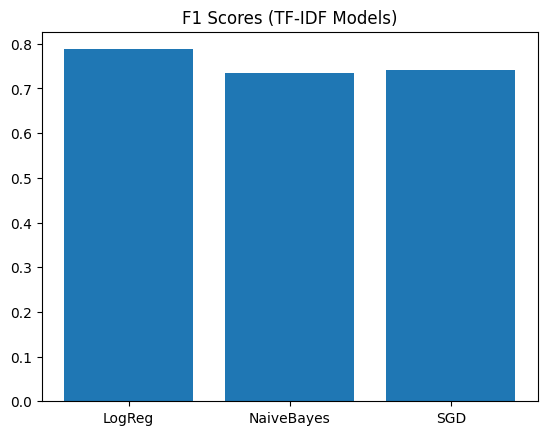


Predicted Sentiment Distribution:
predicted_sentiment
positive    610
negative    339
Name: count, dtype: int64
Topic 0: really, nice, chicago, location, get, view, stay, good, room, hotel
Topic 1: staff, room, location, chicago, place, service, stay, nice, hotel, great
Topic 2: service, one, us, night, desk, get, like, would, hotel, room
Topic 3: small, chicago, one, palmer house, house, palmer, rooms, lobby, room, hotel
Topic 4: got, nice, stayed, bathroom, really, hotel, rooms, could, great, room

Topic Comparison (Model-Based Sentiment):
predicted_sentiment  negative  positive
dominant_topic                         
0                          30       152
1                          21       175
2                         166        72
3                          77       163
4                          45        48


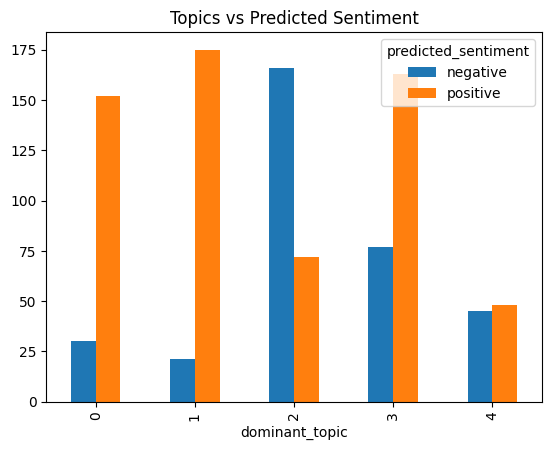


Engagement by Predicted Sentiment:
                     usefulCount  coolCount  funnyCount
predicted_sentiment                                    
negative                0.941003   0.339233    0.486726
positive                0.872131   0.547541    0.318033


In [18]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score

from sklearn.decomposition import LatentDirichletAllocation

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("hotel_final.csv")

# Drop index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.head())
print(df.info())

# ================================
# 3. CLEAN TEXT
# ================================
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['reviewContent'].apply(clean_text)

# ================================
# 4. CREATE TRAINING LABEL (ONLY FOR TRAINING MODEL)
# ================================
# We STILL use rating temporarily to TRAIN the model,
# but final sentiment will come from TEXT predictions
df["pos_rev"] = df["rating"].apply(lambda x: 1 if x >= 4 else 0)

X = df["clean_text"]
y = df["pos_rev"]

# ================================
# 5. TRAIN / TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================================
# 6. COUNT VECTORIZER MODELS
# =====================================================
cv = CountVectorizer(stop_words="english")
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

lr = LogisticRegression(max_iter=1000)
nb = MultinomialNB()
sgd = SGDClassifier()

lr.fit(X_train_cv, y_train)
nb.fit(X_train_cv, y_train)
sgd.fit(X_train_cv, y_train)

models = {"LogReg": lr, "NaiveBayes": nb, "SGD": sgd}

results_cv = []
for name, model in models.items():
    preds = model.predict(X_test_cv)
    results_cv.append([
        name,
        accuracy_score(y_test, preds),
        f1_score(y_test, preds)
    ])

results_cv_df = pd.DataFrame(results_cv, columns=["Model","Accuracy","F1"])
print("\nCountVectorizer Results:")
print(results_cv_df)

# =====================================================
# 7. TF-IDF MODELS
# =====================================================
tfidf = TfidfVectorizer(stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

lr_tfidf = LogisticRegression(max_iter=1000)
nb_tfidf = MultinomialNB()
sgd_tfidf = SGDClassifier()

lr_tfidf.fit(X_train_tfidf, y_train)
nb_tfidf.fit(X_train_tfidf, y_train)
sgd_tfidf.fit(X_train_tfidf, y_train)

models_tfidf = {"LogReg": lr_tfidf, "NaiveBayes": nb_tfidf, "SGD": sgd_tfidf}

results_tfidf = []
for name, model in models_tfidf.items():
    preds = model.predict(X_test_tfidf)
    results_tfidf.append([
        name,
        accuracy_score(y_test, preds),
        f1_score(y_test, preds)
    ])

results_tfidf_df = pd.DataFrame(results_tfidf, columns=["Model","Accuracy","F1"])
print("\nTF-IDF Results:")
print(results_tfidf_df)

# Plot comparison
plt.figure()
plt.bar(results_tfidf_df["Model"], results_tfidf_df["F1"])
plt.title("F1 Scores (TF-IDF Models)")
plt.show()

# =====================================================
# 8. SELECT BEST MODEL
# =====================================================
best_model = lr_tfidf
best_vectorizer = tfidf

# ================================
# 9. PREDICT SENTIMENT FROM TEXT
# ================================
df['predicted_sentiment'] = best_model.predict(
    best_vectorizer.transform(df['clean_text'])
)

df['predicted_sentiment'] = df['predicted_sentiment'].map({
    1: 'positive',
    0: 'negative'
})

print("\nPredicted Sentiment Distribution:")
print(df['predicted_sentiment'].value_counts())

# ================================
# 10. TOPIC MODELING (LDA)
# ================================
vectorizer = CountVectorizer(max_df=0.9, min_df=10, ngram_range=(1,2))
X_topics = vectorizer.fit_transform(df['clean_text'])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_topics)

# Display topics
def display_topics(model, feature_names, n_words):
    for i, topic in enumerate(model.components_):
        words = [feature_names[j] for j in topic.argsort()[-n_words:]]
        print(f"Topic {i}: {', '.join(words)}")

feature_names = vectorizer.get_feature_names_out()
display_topics(lda, feature_names, 10)

# ================================
# 11. ASSIGN TOPICS
# ================================
topic_values = lda.transform(X_topics)
df['dominant_topic'] = topic_values.argmax(axis=1)

# ================================
# 12. COMPARE USING PREDICTED SENTIMENT
# ================================
comparison_df = pd.crosstab(
    df['dominant_topic'],
    df['predicted_sentiment']
)

print("\nTopic Comparison (Model-Based Sentiment):")
print(comparison_df)

comparison_df.plot(kind='bar')
plt.title("Topics vs Predicted Sentiment")
plt.show()

# ================================
# 13. ENGAGEMENT INSIGHT
# ================================
engagement = df.groupby('predicted_sentiment')[
    ['usefulCount','coolCount','funnyCount']
].mean()

print("\nEngagement by Predicted Sentiment:")
print(engagement)

# ================================
# 14. SAVE RESULTS
# ================================
df.to_csv("final_with_predicted_sentiment_topics.csv", index=False)
comparison_df.to_csv("topic_vs_sentiment.csv")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rick\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Sentiment Model Performance:
Accuracy: 0.7526315789473684
F1 Score: 0.7729468599033816

Topic 0:
great, nice, location, chicago, view, good, rooms, staff, service, lake

Topic 1:
service, time, desk, check, wedding, day, called, hyatt, told, didnt

Topic 2:
lobby, rooms, palmer, house, palmer house, great, beautiful, chicago, staff, old

Topic 3:
dont, floor, like, didnt, bathroom, know, way, service, desk, staff

Topic 4:
like, nice, good, lobby, rooms, bar, bathroom, bed, small, great

Topic vs Sentiment:
predicted_sentiment  negative  positive
dominant_topic                         
0                          99       268
1                          81        36
2                         105       150
3                          65        27
4                          53        65


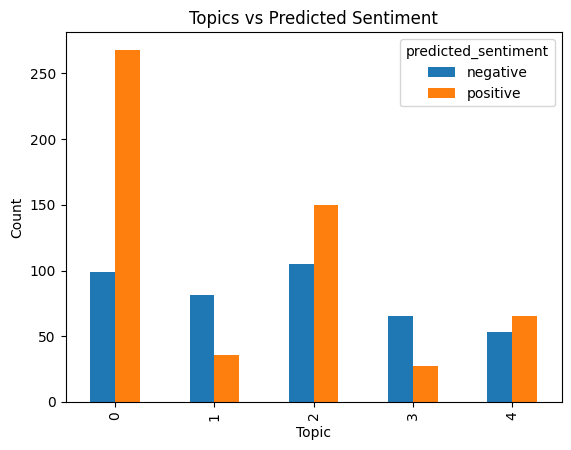


Most Common Topics in Negative Reviews:
dominant_topic
2    105
0     99
1     81
3     65
4     53
Name: count, dtype: int64


In [19]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("hotel_final.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# ================================
# 3. CUSTOM STOPWORDS (FIXED)
# ================================
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = set(stopwords.words('english')).union(ENGLISH_STOP_WORDS)

domain_words = {
    "hotel","room","stay","stayed","night","nights",
    "place","property","really","got","went","one",
    "would","could","also","us","im","ive"
}

# 🔥 FIX: convert to list
all_stopwords = list(custom_stopwords.union(domain_words))

# ================================
# 4. CLEAN TEXT
# ================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in all_stopwords and len(w) > 2]
    return " ".join(words)

df['clean_text'] = df['reviewContent'].apply(clean_text)

# ================================
# 5. TRAIN SENTIMENT MODEL (TEXT-BASED)
# ================================
df["pos_rev"] = df["rating"].apply(lambda x: 1 if x >= 4 else 0)

X = df["clean_text"]
y = df["pos_rev"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer_sent = CountVectorizer(
    stop_words=all_stopwords,
    ngram_range=(1,2),
    min_df=5
)

X_train_vec = vectorizer_sent.fit_transform(X_train)
X_test_vec = vectorizer_sent.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

preds = model.predict(X_test_vec)

print("\nSentiment Model Performance:")
print("Accuracy:", accuracy_score(y_test, preds))
print("F1 Score:", f1_score(y_test, preds))

# ================================
# 6. PREDICT SENTIMENT FROM TEXT
# ================================
df['predicted_sentiment'] = model.predict(
    vectorizer_sent.transform(df['clean_text'])
)

df['predicted_sentiment'] = df['predicted_sentiment'].map({
    1: 'positive',
    0: 'negative'
})

# ================================
# 7. VECTORIZATION FOR TOPICS
# ================================
topic_vectorizer = CountVectorizer(
    stop_words=all_stopwords,
    ngram_range=(1,3),   # 🔥 KEY CHANGE
    max_df=0.85,         # remove overly common phrases
    min_df=15            # keep meaningful phrases
)

X_topics = topic_vectorizer.fit_transform(df['clean_text'])

# ================================
# 8. LDA TOPIC MODEL
# ================================
num_topics = 5

lda = LatentDirichletAllocation(
    n_components=num_topics,
    random_state=42
)

lda.fit(X_topics)

# ================================
# 9. DISPLAY CLEANER TOPICS
# ================================
def display_topics(model, feature_names, n_words):
    for i, topic in enumerate(model.components_):
        words = [feature_names[j] for j in topic.argsort()[-n_words:]]
        print(f"\nTopic {i}:")
        print(", ".join(words[::-1]))  # reverse for readability

feature_names = topic_vectorizer.get_feature_names_out()
display_topics(lda, feature_names, 10)

# ================================
# 10. ASSIGN DOMINANT TOPIC
# ================================
topic_values = lda.transform(X_topics)
df['dominant_topic'] = topic_values.argmax(axis=1)

# ================================
# 11. COMPARE SENTIMENT VS TOPICS
# ================================
comparison_df = pd.crosstab(
    df['dominant_topic'],
    df['predicted_sentiment']
)

print("\nTopic vs Sentiment:")
print(comparison_df)

comparison_df.plot(kind='bar')
plt.title("Topics vs Predicted Sentiment")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.show()

# ================================
# 12. NEGATIVE TOPIC INSIGHTS
# ================================
neg_topics = df[df['predicted_sentiment'] == 'negative']['dominant_topic'].value_counts()

print("\nMost Common Topics in Negative Reviews:")
print(neg_topics)

# ================================
# 13. SAVE RESULTS
# ================================
df.to_csv("final_clean_topics.csv", index=False)
comparison_df.to_csv("topic_sentiment_clean.csv")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rick\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                 reviewID                                      reviewContent  \
0      -ZkzDLAp-6LSdek-nU  My husband took me to stay the night for a fun...   
1  9yStfyRS5CISu-May43dmA  stayed at the property over the weekend, got a...   
2  Wf-7bJszS2n6REXGbrwK2w  Overall, I think I'm less and less a fan of th...   
3                     ZLe  I'd like to make a confession. I don't really ...   
4  vURf9AGmThDrRC9TVcQrdw  The good:  the view; location The bad:  servic...   

   rating  usefulCount  coolCount  funnyCount  
0       4            0          0           0  
1       3            0          0           0  
2       3            0          0           0  
3       3           21         11          16  
4       1            0          0           0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949 entries, 0 to 948
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   reviewID       949 non-null    objec

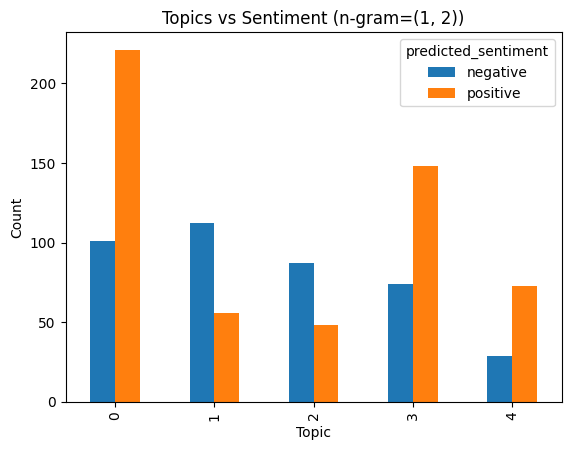


TOPICS USING N-GRAM RANGE: (2, 3)

Topic 0:
staff friendly, view lake, dont know, dont think, lake michigan, bliss spa, make sure, lake view, location close, youre going

Topic 1:
hyatt regency, free internet, lobby area, lobby beautiful, highly recommend, coffee maker, west tower, comfortable bed, block away, beds comfortable

Topic 2:
walking distance, customer service, michigan ave, navy pier, house hilton, palmer house hilton, big bar, millennium park, new years, water pressure

Topic 3:
navy pier, free wifi, downtown chicago, flat screen, hotels chicago, lobby bar, magnificent mile, ive seen, hyatt regency, beautiful lobby

Topic 4:
palmer house, millenium park, michigan avenue, art institute, bed comfortable, blocks away, water pressure, millennium park, beautiful lobby, coffee maker

Topic vs Sentiment:
predicted_sentiment    negative  positive
dominant_topic_(2, 3)                    
0                           209       279
1                            51        60
2        

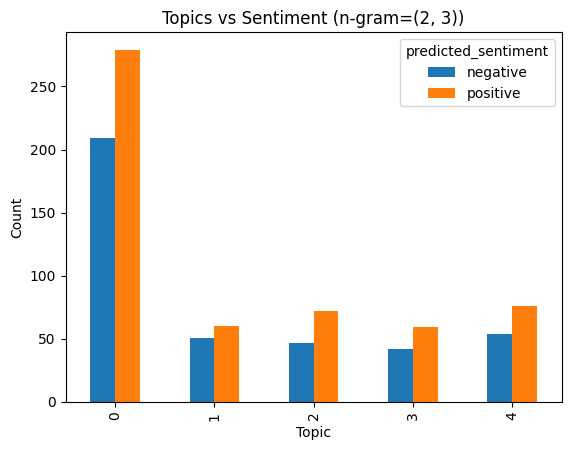


TOPICS USING N-GRAM RANGE: (3, 4)

Topic 0:
palmer house hilton

Topic 1:
palmer house hilton

Topic 2:
palmer house hilton

Topic 3:
palmer house hilton

Topic 4:
palmer house hilton

Topic vs Sentiment:
predicted_sentiment    negative  positive
dominant_topic_(3, 4)                    
0                           403       546


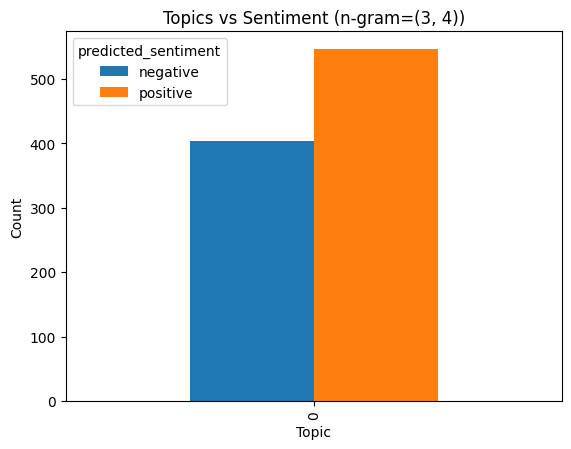


Average Review Length by Sentiment:
predicted_sentiment
negative    70.493797
positive    52.252747
Name: review_length, dtype: float64

Engagement by Sentiment:
                     usefulCount  coolCount  funnyCount
predicted_sentiment                                    
negative                0.908189   0.352357    0.429280
positive                0.888278   0.562271    0.340659

Top Words in Negative Reviews:
         word  count
423   service    219
274     lobby    191
76    chicago    174
34        bed    169
484      time    166
122      desk    163
197       got    160
276  location    143
453     staff    142
31   bathroom    140
124     didnt    139
133      dont    133
177     floor    131
439     small    121
114       day    120


In [20]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("hotel_final.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.head())
print(df.info())

# ================================
# 3. STRONG STOPWORDS
# ================================
base_stopwords = set(stopwords.words('english')).union(ENGLISH_STOP_WORDS)

generic_words = {
    "good","great","nice","amazing","awesome","excellent",
    "bad","okay","ok","fine","perfect","love","like",
    "really","very","pretty","much","lot","little"
}

domain_words = {
    "hotel","room","rooms","stay","stayed","night","nights",
    "place","property","trip","visit"
}

# FIX: convert to list
all_stopwords = list(base_stopwords.union(generic_words).union(domain_words))

# ================================
# 4. CLEAN TEXT
# ================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in all_stopwords and len(w) > 2]
    return " ".join(words)

df['clean_text'] = df['reviewContent'].apply(clean_text)

# ================================
# 5. TRAIN SENTIMENT MODEL
# ================================
df["pos_rev"] = df["rating"].apply(lambda x: 1 if x >= 4 else 0)

X = df["clean_text"]
y = df["pos_rev"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer_sent = CountVectorizer(
    stop_words=all_stopwords,
    ngram_range=(1,2),
    min_df=5
)

X_train_vec = vectorizer_sent.fit_transform(X_train)
X_test_vec = vectorizer_sent.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

preds = model.predict(X_test_vec)

print("\nSentiment Model Performance:")
print("Accuracy:", accuracy_score(y_test, preds))
print("F1 Score:", f1_score(y_test, preds))

# ================================
# 6. PREDICT SENTIMENT FROM TEXT
# ================================
df['predicted_sentiment'] = model.predict(
    vectorizer_sent.transform(df['clean_text'])
)

df['predicted_sentiment'] = df['predicted_sentiment'].map({
    1: 'positive',
    0: 'negative'
})

print("\nPredicted Sentiment Distribution:")
print(df['predicted_sentiment'].value_counts())

# ================================
# 7. FUNCTION TO DISPLAY TOPICS
# ================================
def display_topics(model, feature_names, n_words=10):
    for i, topic in enumerate(model.components_):
        words = [feature_names[j] for j in topic.argsort()[-n_words:]]
        print(f"\nTopic {i}:")
        print(", ".join(words[::-1]))

# ================================
# 8. LOOP THROUGH N-GRAM RANGES
# ================================
ngram_ranges = [(1,2), (2,3), (3,4)]

for ngram in ngram_ranges:
    
    print("\n" + "="*60)
    print(f"TOPICS USING N-GRAM RANGE: {ngram}")
    print("="*60)
    
    topic_vectorizer = CountVectorizer(
        stop_words=all_stopwords,
        ngram_range=ngram,
        max_df=0.85,
        min_df=15,
        token_pattern=r'\b[a-zA-Z]{3,}\b'
    )
    
    X_topics = topic_vectorizer.fit_transform(df['clean_text'])
    
    lda = LatentDirichletAllocation(
        n_components=5,
        random_state=42
    )
    
    lda.fit(X_topics)
    
    feature_names = topic_vectorizer.get_feature_names_out()
    
    display_topics(lda, feature_names)
    
    # ================================
    # 9. ASSIGN DOMINANT TOPIC
    # ================================
    topic_values = lda.transform(X_topics)
    df[f'dominant_topic_{ngram}'] = topic_values.argmax(axis=1)
    
    # ================================
    # 10. COMPARE TOPICS VS SENTIMENT
    # ================================
    comparison_df = pd.crosstab(
        df[f'dominant_topic_{ngram}'],
        df['predicted_sentiment']
    )
    
    print("\nTopic vs Sentiment:")
    print(comparison_df)
    
    comparison_df.plot(kind='bar')
    plt.title(f"Topics vs Sentiment (n-gram={ngram})")
    plt.xlabel("Topic")
    plt.ylabel("Count")
    plt.show()

# ================================
# 11. REVIEW LENGTH ANALYSIS
# ================================
df['review_length'] = df['clean_text'].apply(lambda x: len(x.split()))

print("\nAverage Review Length by Sentiment:")
print(df.groupby('predicted_sentiment')['review_length'].mean())

# ================================
# 12. ENGAGEMENT ANALYSIS
# ================================
engagement = df.groupby('predicted_sentiment')[
    ['usefulCount','coolCount','funnyCount']
].mean()

print("\nEngagement by Sentiment:")
print(engagement)

# ================================
# 13. NEGATIVE WORD ANALYSIS
# ================================
neg_df = df[df['predicted_sentiment'] == 'negative']

neg_vectorizer = CountVectorizer(
    stop_words=all_stopwords,
    max_df=0.9,
    min_df=10
)

X_neg = neg_vectorizer.fit_transform(neg_df['clean_text'])

word_counts = np.asarray(X_neg.sum(axis=0)).flatten()
words = neg_vectorizer.get_feature_names_out()

word_freq = pd.DataFrame({
    'word': words,
    'count': word_counts
}).sort_values(by='count', ascending=False)

print("\nTop Words in Negative Reviews:")
print(word_freq.head(15))

# ================================
# 14. SAVE OUTPUTS
# ================================
df.to_csv("final_analysis_output.csv", index=False)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rick\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                 reviewID                                      reviewContent  \
0      -ZkzDLAp-6LSdek-nU  My husband took me to stay the night for a fun...   
1  9yStfyRS5CISu-May43dmA  stayed at the property over the weekend, got a...   
2  Wf-7bJszS2n6REXGbrwK2w  Overall, I think I'm less and less a fan of th...   
3                     ZLe  I'd like to make a confession. I don't really ...   
4  vURf9AGmThDrRC9TVcQrdw  The good:  the view; location The bad:  servic...   

   rating  usefulCount  coolCount  funnyCount  
0       4            0          0           0  
1       3            0          0           0  
2       3            0          0           0  
3       3           21         11          16  
4       1            0          0           0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949 entries, 0 to 948
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   reviewID       949 non-null    objec

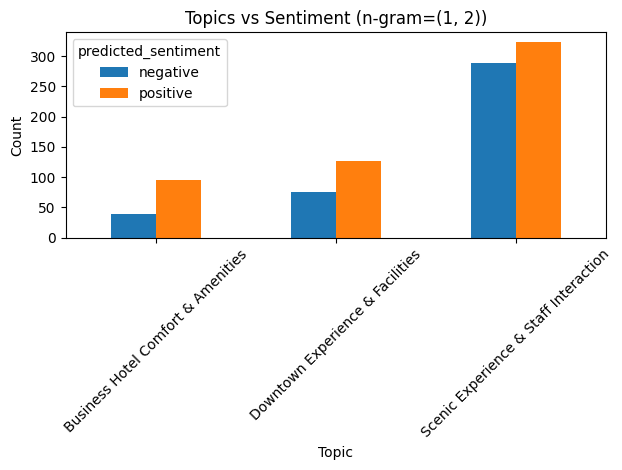


TOPICS USING N-GRAM RANGE: (2, 3)

Topic 0:
palmer house, customer service, navy pier, lake view, wireless internet, dont think, state street, called desk, double beds, city center

Topic 1:
view lake, michigan ave, lobby bar, lake michigan, navy pier, bliss spa, bliss products, flat screen, staff friendly, lobby area

Topic 2:
palmer house, hyatt regency, big bar, millenium park, new years, comfortable bed, executive level, years eve, new years eve, service food

Topic 3:
navy pier, hotels chicago, west tower, time chicago, michigan avenue, coffee maker, public transportation, location location, magnificent mile, staff helpful

Topic 4:
palmer house, walking distance, staff friendly, palmer house hilton, house hilton, free wifi, millennium park, make sure, got deal, art institute

REFINED TOPIC LABELS:
Topic 0: Scenic Experience & Staff Interaction
Topic 1: Scenic Experience & Staff Interaction
Topic 2: Business Hotel Comfort & Amenities
Topic 3: Scenic Experience & Staff Interaction

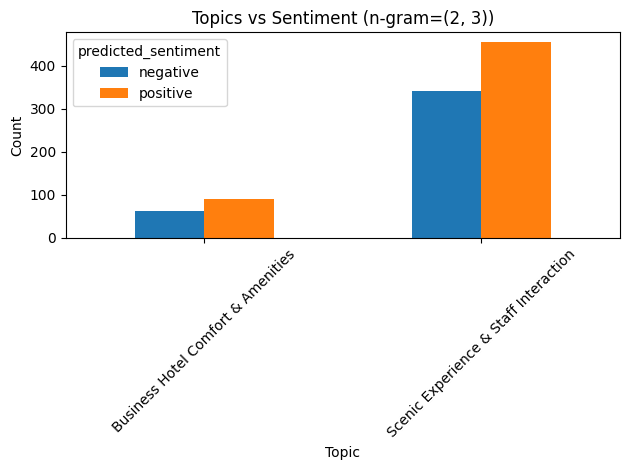


Average Review Length by Sentiment:
predicted_sentiment
negative    70.493797
positive    52.252747
Name: review_length, dtype: float64

Engagement by Sentiment:
                     usefulCount  coolCount  funnyCount
predicted_sentiment                                    
negative                0.908189   0.352357    0.429280
positive                0.888278   0.562271    0.340659

Top Words in Negative Reviews:
         word  count
423   service    219
274     lobby    191
76    chicago    174
34        bed    169
484      time    166
122      desk    163
197       got    160
276  location    143
453     staff    142
31   bathroom    140
124     didnt    139
133      dont    133
177     floor    131
439     small    121
114       day    120


In [21]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("hotel_final.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.head())
print(df.info())

# ================================
# 3. STOPWORDS
# ================================
base_stopwords = set(stopwords.words('english')).union(ENGLISH_STOP_WORDS)

generic_words = {
    "good","great","nice","amazing","awesome","excellent",
    "bad","okay","ok","fine","perfect","love","like",
    "really","very","pretty","much","lot","little"
}

domain_words = {
    "hotel","room","rooms","stay","stayed","night","nights",
    "place","property","trip","visit"
}

all_stopwords = list(base_stopwords.union(generic_words).union(domain_words))

# ================================
# 4. CLEAN TEXT
# ================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in all_stopwords and len(w) > 2]
    return " ".join(words)

df['clean_text'] = df['reviewContent'].apply(clean_text)

# ================================
# 5. SENTIMENT MODEL
# ================================
df["pos_rev"] = df["rating"].apply(lambda x: 1 if x >= 4 else 0)

X = df["clean_text"]
y = df["pos_rev"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer_sent = CountVectorizer(
    stop_words=all_stopwords,
    ngram_range=(1,2),
    min_df=5
)

X_train_vec = vectorizer_sent.fit_transform(X_train)
X_test_vec = vectorizer_sent.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

preds = model.predict(X_test_vec)

print("\nSentiment Model Performance:")
print("Accuracy:", accuracy_score(y_test, preds))
print("F1 Score:", f1_score(y_test, preds))

# ================================
# 6. PREDICT SENTIMENT
# ================================
df['predicted_sentiment'] = model.predict(
    vectorizer_sent.transform(df['clean_text'])
)

df['predicted_sentiment'] = df['predicted_sentiment'].map({
    1: 'positive',
    0: 'negative'
})

print("\nPredicted Sentiment Distribution:")
print(df['predicted_sentiment'].value_counts())

# ================================
# 7. DISPLAY TOPICS FUNCTION
# ================================
def display_topics(model, feature_names, n_words=10):
    topics = []
    for i, topic in enumerate(model.components_):
        words = [feature_names[j] for j in topic.argsort()[-n_words:]]
        topic_words = ", ".join(words[::-1])
        topics.append(topic_words)
        print(f"\nTopic {i}:")
        print(topic_words)
    return topics

# ================================
# 8. REFLECTIVE TOPIC LABELING (NEW)
# ================================
def label_topics(topics):
    labels = []
    for t in topics:
        t = t.lower()

        if any(x in t for x in ["lake", "view", "spa", "staff"]):
            labels.append("Scenic Experience & Staff Interaction")

        elif any(x in t for x in ["hyatt", "regency", "bed", "coffee", "internet"]):
            labels.append("Business Hotel Comfort & Amenities")

        elif any(x in t for x in ["navy pier", "millennium", "michigan", "walking"]):
            labels.append("Tourist Location & Accessibility")

        elif any(x in t for x in ["downtown", "lobby", "wifi", "bar"]):
            labels.append("Downtown Experience & Facilities")

        elif any(x in t for x in ["palmer", "art institute", "historic"]):
            labels.append("Landmark Hotel & Cultural Experience")

        else:
            labels.append("General Experience Theme")

    return labels

# ================================
# 9. IMPROVED LDA LOOP
# ================================
ngram_ranges = [(1,2), (2,3)]

for ngram in ngram_ranges:

    print("\n" + "="*60)
    print(f"TOPICS USING N-GRAM RANGE: {ngram}")
    print("="*60)

    topic_vectorizer = CountVectorizer(
        stop_words=all_stopwords,
        ngram_range=ngram,
        max_df=0.9,
        min_df=5,
        token_pattern=r'\b[a-zA-Z]{3,}\b'
    )

    X_topics = topic_vectorizer.fit_transform(df['clean_text'])

    lda = LatentDirichletAllocation(
        n_components=5,
        random_state=42
    )

    lda.fit(X_topics)

    feature_names = topic_vectorizer.get_feature_names_out()

    raw_topics = display_topics(lda, feature_names)

    # ================================
    # 10. ASSIGN TOPIC + LABEL
    # ================================
    topic_values = lda.transform(X_topics)
    df[f'dominant_topic_{ngram}'] = topic_values.argmax(axis=1)

    topic_labels = label_topics(raw_topics)
    topic_label_map = dict(enumerate(topic_labels))

    df[f'topic_label_{ngram}'] = df[f'dominant_topic_{ngram}'].map(topic_label_map)

    print("\nREFINED TOPIC LABELS:")
    for i, label in topic_label_map.items():
        print(f"Topic {i}: {label}")

    # ================================
    # 11. TOPIC VS SENTIMENT
    # ================================
    comparison_df = pd.crosstab(
        df[f'topic_label_{ngram}'],
        df['predicted_sentiment']
    )

    print("\nTopic vs Sentiment:")
    print(comparison_df)

    comparison_df.plot(kind='bar')
    plt.title(f"Topics vs Sentiment (n-gram={ngram})")
    plt.xlabel("Topic")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ================================
# 12. REVIEW LENGTH ANALYSIS
# ================================
df['review_length'] = df['clean_text'].apply(lambda x: len(x.split()))

print("\nAverage Review Length by Sentiment:")
print(df.groupby('predicted_sentiment')['review_length'].mean())

# ================================
# 13. ENGAGEMENT ANALYSIS
# ================================
engagement = df.groupby('predicted_sentiment')[
    ['usefulCount','coolCount','funnyCount']
].mean()

print("\nEngagement by Sentiment:")
print(engagement)

# ================================
# 14. NEGATIVE WORD ANALYSIS
# ================================
neg_df = df[df['predicted_sentiment'] == 'negative']

neg_vectorizer = CountVectorizer(
    stop_words=all_stopwords,
    max_df=0.9,
    min_df=10
)

X_neg = neg_vectorizer.fit_transform(neg_df['clean_text'])

word_counts = np.asarray(X_neg.sum(axis=0)).flatten()
words = neg_vectorizer.get_feature_names_out()

word_freq = pd.DataFrame({
    'word': words,
    'count': word_counts
}).sort_values(by='count', ascending=False)

print("\nTop Words in Negative Reviews:")
print(word_freq.head(15))

# ================================
# 15. SAVE OUTPUT
# ================================
df.to_csv("final_analysis_output.csv", index=False)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rick\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy: 0.7578947368421053
F1: 0.7766990291262136

TOPICS USING N-GRAM RANGE: (1, 2)

Topic 0: got, time, chicago, bed, desk, service, dont, didnt, view, bathroom

Topic 1: lobby, service, internet, floor, staff, house, free, use, palmer, palmer house

Topic 2: lobby, time, palmer, wedding, house, palmer house, chicago, service, beautiful, didnt

Topic 3: location, view, chicago, bar, staff, service, hyatt, bathroom, hotels, lake

Topic 4: chicago, park, location, bed, lobby, service, got, old, small, bar


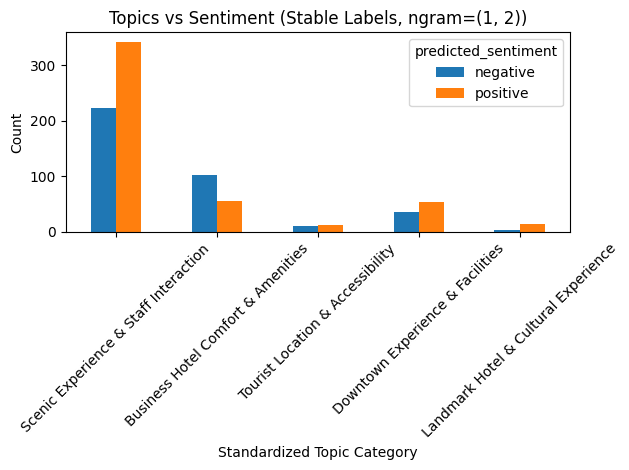


TOPICS USING N-GRAM RANGE: (2, 3)

Topic 0: palmer house, customer service, navy pier, lake view, wireless internet, dont think, state street, called desk, double beds, city center

Topic 1: view lake, michigan ave, lobby bar, lake michigan, navy pier, bliss spa, bliss products, flat screen, staff friendly, lobby area

Topic 2: palmer house, hyatt regency, big bar, millenium park, new years, comfortable bed, executive level, years eve, new years eve, service food

Topic 3: navy pier, hotels chicago, west tower, time chicago, michigan avenue, coffee maker, public transportation, location location, magnificent mile, staff helpful

Topic 4: palmer house, walking distance, staff friendly, palmer house hilton, house hilton, free wifi, millennium park, make sure, got deal, art institute


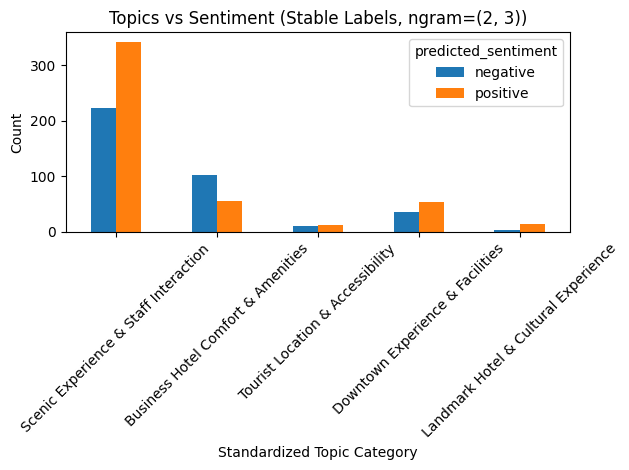

predicted_sentiment
negative    70.493797
positive    52.252747
Name: review_length, dtype: float64
                     usefulCount  coolCount  funnyCount
predicted_sentiment                                    
negative                0.908189   0.352357    0.429280
positive                0.888278   0.562271    0.340659
         word  count
423   service    219
274     lobby    191
76    chicago    174
34        bed    169
484      time    166
122      desk    163
197       got    160
276  location    143
453     staff    142
31   bathroom    140
124     didnt    139
133      dont    133
177     floor    131
439     small    121
114       day    120


In [22]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("hotel_final.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# ================================
# 3. STOPWORDS
# ================================
base_stopwords = set(stopwords.words('english')).union(ENGLISH_STOP_WORDS)

generic_words = {
    "good","great","nice","amazing","awesome","excellent",
    "bad","okay","ok","fine","perfect","love","like",
    "really","very","pretty","much","lot","little"
}

domain_words = {
    "hotel","room","rooms","stay","stayed","night","nights",
    "place","property","trip","visit"
}

all_stopwords = list(base_stopwords.union(generic_words).union(domain_words))

# ================================
# 4. CLEAN TEXT
# ================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in all_stopwords and len(w) > 2]
    return " ".join(words)

df['clean_text'] = df['reviewContent'].apply(clean_text)

# ================================
# 5. SENTIMENT MODEL
# ================================
df["pos_rev"] = df["rating"].apply(lambda x: 1 if x >= 4 else 0)

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["pos_rev"],
    test_size=0.2, random_state=42
)

vectorizer_sent = CountVectorizer(
    stop_words=all_stopwords,
    ngram_range=(1,2),
    min_df=5
)

X_train_vec = vectorizer_sent.fit_transform(X_train)
X_test_vec = vectorizer_sent.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

preds = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, preds))
print("F1:", f1_score(y_test, preds))

df['predicted_sentiment'] = model.predict(
    vectorizer_sent.transform(df['clean_text'])
)

df['predicted_sentiment'] = df['predicted_sentiment'].map({
    1: 'positive',
    0: 'negative'
})

# ================================
# 6. FIXED TOPIC LABEL SYSTEM (CORE CHANGE)
# ================================
STANDARD_LABELS = [
    "Scenic Experience & Staff Interaction",
    "Business Hotel Comfort & Amenities",
    "Tourist Location & Accessibility",
    "Downtown Experience & Facilities",
    "Landmark Hotel & Cultural Experience"
]

def assign_standard_label(text):
    t = text.lower()

    if any(x in t for x in ["lake", "view", "spa", "staff"]):
        return "Scenic Experience & Staff Interaction"

    elif any(x in t for x in ["hyatt", "regency", "bed", "coffee", "internet"]):
        return "Business Hotel Comfort & Amenities"

    elif any(x in t for x in ["navy pier", "millennium", "michigan", "walking"]):
        return "Tourist Location & Accessibility"

    elif any(x in t for x in ["downtown", "lobby", "wifi", "bar"]):
        return "Downtown Experience & Facilities"

    elif any(x in t for x in ["palmer", "art institute", "historic"]):
        return "Landmark Hotel & Cultural Experience"

    else:
        return "General Experience Theme"

# ================================
# 7. LDA LOOP (NOW STANDARDIZED OUTPUT)
# ================================
ngram_ranges = [(1,2), (2,3)]

for ngram in ngram_ranges:

    print("\n" + "="*60)
    print(f"TOPICS USING N-GRAM RANGE: {ngram}")
    print("="*60)

    vectorizer = CountVectorizer(
        stop_words=all_stopwords,
        ngram_range=ngram,
        max_df=0.9,
        min_df=5,
        token_pattern=r'\b[a-zA-Z]{3,}\b'
    )

    X_topics = vectorizer.fit_transform(df['clean_text'])

    lda = LatentDirichletAllocation(
        n_components=5,
        random_state=42
    )

    lda.fit(X_topics)

    feature_names = vectorizer.get_feature_names_out()

    # raw topic words (for inspection only)
    for i, topic in enumerate(lda.components_):
        words = [feature_names[j] for j in topic.argsort()[-10:]][::-1]
        print(f"\nTopic {i}: {', '.join(words)}")

    # ================================
    # 8. ASSIGN STANDARD LABELS (KEY FIX)
    # ================================
    topic_dist = lda.transform(X_topics)
    topic_ids = topic_dist.argmax(axis=1)

    df[f"topic_id_{ngram}"] = topic_ids

    # convert each topic into stable label
    df[f"topic_label_{ngram}"] = df['clean_text'].apply(assign_standard_label)

    # ================================
    # 9. FORCE CONSISTENT ORDER FOR PLOTTING
    # ================================
    plot_data = df.groupby(f"topic_label_{ngram}")['predicted_sentiment'].value_counts().unstack().fillna(0)

    # enforce order
    plot_data = plot_data.reindex(STANDARD_LABELS, fill_value=0)

    # ================================
    # 10. PLOT (STABLE X-AXIS)
    # ================================
    plot_data.plot(kind='bar')

    plt.title(f"Topics vs Sentiment (Stable Labels, ngram={ngram})")
    plt.xlabel("Standardized Topic Category")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ================================
# 11. REVIEW LENGTH ANALYSIS
# ================================
df['review_length'] = df['clean_text'].apply(lambda x: len(x.split()))

print(df.groupby('predicted_sentiment')['review_length'].mean())

# ================================
# 12. ENGAGEMENT ANALYSIS
# ================================
print(
    df.groupby('predicted_sentiment')[
        ['usefulCount','coolCount','funnyCount']
    ].mean()
)

# ================================
# 13. NEGATIVE WORD ANALYSIS
# ================================
neg_df = df[df['predicted_sentiment'] == 'negative']

neg_vec = CountVectorizer(
    stop_words=all_stopwords,
    min_df=10,
    max_df=0.9
)

X_neg = neg_vec.fit_transform(neg_df['clean_text'])

word_counts = np.asarray(X_neg.sum(axis=0)).flatten()
words = neg_vec.get_feature_names_out()

top_words = pd.DataFrame({
    "word": words,
    "count": word_counts
}).sort_values(by="count", ascending=False)

print(top_words.head(15))

# ================================
# 14. SAVE OUTPUT
# ================================
df.to_csv("final_analysis_output.csv", index=False)

In [24]:
pip install bertopic sentence-transformers

  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 571.3/571.3 kB 12.0 MB/s  0:00:00
   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   ---------------------------------------- 10.2/10.2 MB 63.4 MB/s  0:00:00
   ---------------------------------------- 0.0/645.5 kB ? eta -:--:--
   ---------------------------------------- 645.5/645.5 kB 31.2 MB/s  0:00:00
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---------------------------------------- 3.7/3.7 MB 66.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 50.6 MB/s  0:00:00
   ---------------------------------------- 0.0/670.6 kB ? eta -:--:--
   ---------------------------------------- 670.6/670.6 kB 31.8 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 

In [36]:
# ================================
# 1. IMPORT LIBRARIES (HUGGING FACE STACK)
# ================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

from sklearn.feature_extraction.text import CountVectorizer

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# OPTIONAL (Hugging Face sentiment instead of sklearn)
from transformers import pipeline

# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("hotel_final.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# ================================
# 3. STOPWORDS
# ================================
base_stopwords = set(stopwords.words('english'))

generic_words = {
    "good","great","nice","amazing","awesome","excellent",
    "bad","okay","ok","fine","perfect","love","like",
    "really","very","pretty","much","lot","little"
}

domain_words = {
    "hotel","room","rooms","stay","stayed","night","nights",
    "place","property","trip","visit"
}

all_stopwords = list(base_stopwords.union(generic_words).union(domain_words))

# ================================
# 4. CLEAN TEXT
# ================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in all_stopwords and len(w) > 2]
    return " ".join(words)

df["clean_text"] = df["reviewContent"].apply(clean_text)

docs = df["clean_text"].tolist()

# ================================
# 5. SENTENCE EMBEDDINGS (HUGGING FACE)
# ================================
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
# embeddings = embedding_model.encode(docs, show_progress_bar=True)
embeddings = embedding_model.encode(
    docs,
    show_progress_bar=True,
    truncation=True,
    max_length=512
)


# ================================
# 6. VECTORIZE FOR TOPIC REPRESENTATION
# ================================
vectorizer_model = CountVectorizer(
    stop_words=all_stopwords,
    ngram_range=(1,2),
    min_df=5
)

# ================================
# 7. BERTopic MODEL (REPLACES LDA)
# ================================
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    nr_topics=5,        # keep comparable to your LDA setup
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

df["topic_id"] = topics

# ================================
# 8. OPTIONAL: HUGGING FACE SENTIMENT MODEL
# ================================
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

df["hf_sentiment"] = df["reviewContent"].apply(
    lambda x: sentiment_model(str(x))[0]["label"]
)

df["hf_sentiment"] = df["hf_sentiment"].str.lower()

# ================================
# 9. FIXED BUSINESS TOPIC LABELS (YOUR STANDARD AXIS)
# ================================
STANDARD_LABELS = [
    "Scenic Experience & Staff Interaction",
    "Business Hotel Comfort & Amenities",
    "Tourist Location & Accessibility",
    "Downtown Experience & Facilities",
    "Landmark Hotel & Cultural Experience",
    "General Experience Theme"
]

def assign_standard_label(text):
    t = text.lower()

    if any(x in t for x in ["lake", "view", "spa", "staff"]):
        return "Scenic Experience & Staff Interaction"

    elif any(x in t for x in ["hyatt", "regency", "bed", "coffee", "internet"]):
        return "Business Hotel Comfort & Amenities"

    elif any(x in t for x in ["navy pier", "millennium", "michigan", "walking"]):
        return "Tourist Location & Accessibility"

    elif any(x in t for x in ["downtown", "lobby", "wifi", "bar"]):
        return "Downtown Experience & Facilities"

    elif any(x in t for x in ["palmer", "art institute", "historic"]):
        return "Landmark Hotel & Cultural Experience"

    else:
        return "General Experience Theme"

df["topic_label"] = df["clean_text"].apply(assign_standard_label)

# ================================
# 10. TOPIC INSPECTION (BERTopic OUTPUT)
# ================================
print("\n=== BERTopic Learned Topics ===")
for topic_id in set(topics):
    if topic_id != -1:
        print(f"\nTopic {topic_id}:")
        print(topic_model.get_topic(topic_id))

# ================================
# 11. SENTIMENT VS STANDARD TOPICS (STABLE X-AXIS)
# ================================
plot_data = pd.crosstab(
    df["topic_label"],
    df["hf_sentiment"]
)

# enforce consistent ordering
plot_data = plot_data.reindex(STANDARD_LABELS, fill_value=0)

plot_data.plot(kind="bar")

plt.title("Topic vs Sentiment (Hugging Face + BERTopic)")
plt.xlabel("Standardized Topic Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ================================
# 12. REVIEW LENGTH ANALYSIS
# ================================
df["review_length"] = df["clean_text"].apply(lambda x: len(x.split()))

print("\nAverage Review Length by Sentiment:")
print(df.groupby("hf_sentiment")["review_length"].mean())

# ================================
# 13. ENGAGEMENT ANALYSIS
# ================================
print("\nEngagement by Sentiment:")
print(
    df.groupby("hf_sentiment")[
        ["usefulCount", "coolCount", "funnyCount"]
    ].mean()
)

# ================================
# 14. NEGATIVE WORD ANALYSIS (HF SENTIMENT)
# ================================
neg_df = df[df["hf_sentiment"] == "negative"]

neg_vec = CountVectorizer(
    stop_words=all_stopwords,
    min_df=10,
    max_df=0.9
)

X_neg = neg_vec.fit_transform(neg_df["clean_text"])

word_counts = np.asarray(X_neg.sum(axis=0)).flatten()
words = neg_vec.get_feature_names_out()

top_words = pd.DataFrame({
    "word": words,
    "count": word_counts
}).sort_values(by="count", ascending=False)

print("\nTop Words in Negative Reviews:")
print(top_words.head(15))

# ================================
# 15. SAVE OUTPUT
# ================================
df.to_csv("final_hf_analysis_output.csv", index=False)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rick\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8910.80it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ValueError: SentenceTransformer.encode() has been called with additional keyword arguments that this model does not use: ['truncation', 'max_length']. As per SentenceTransformer.get_model_kwargs(), this model does not accept any additional keyword arguments.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rick\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13236.92it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 30/30 [00:05<00:00,  5.33it/s]
2026-04-23 20:31:15,303 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-23 20:31:16,027 - BERTopic - Dimensionality - Completed ✓
2026-04-23 20:31:16,028 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-23 20:31:16,065 - BERTopic - Cluster - Completed ✓
2026-04-23 20:31:16,066 - BERTopic - Representation - Extracting topics using c-TF-I


=== BERTopic Topics ===

Topic 0 → Service & Staff Experience
[('lobby', np.float64(0.07100078240092844)), ('bar', np.float64(0.061568612833565024)), ('one', np.float64(0.05944766204488333)), ('get', np.float64(0.059230998333869946)), ('location', np.float64(0.05626370179463469)), ('service', np.float64(0.054342366380307046)), ('time', np.float64(0.0528792510066701)), ('would', np.float64(0.04964994619185625)), ('staff', np.float64(0.04964418503196231)), ('beautiful', np.float64(0.04552767614870445))]

Topic 1 → Service & Staff Experience
[('would', np.float64(0.08284148466719678)), ('one', np.float64(0.07135541102586386)), ('get', np.float64(0.06503161749545908)), ('bed', np.float64(0.0643710422038596)), ('service', np.float64(0.0602662467332923)), ('could', np.float64(0.05442661626726158)), ('back', np.float64(0.05419073293357472)), ('didnt', np.float64(0.05375468273309785)), ('floor', np.float64(0.053117777079732274)), ('time', np.float64(0.052349571855909126))]

Topic 2 → Location

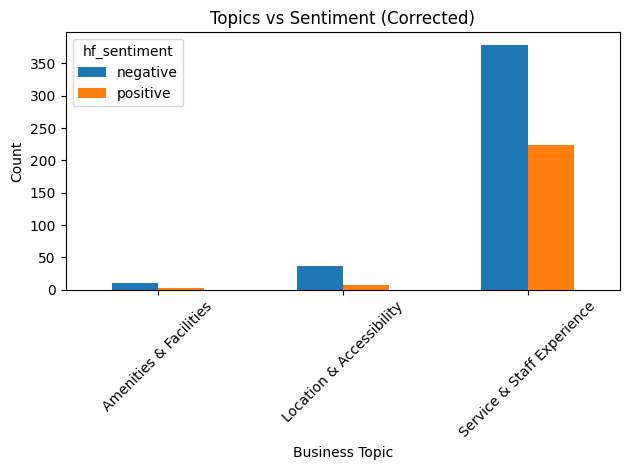


Review Length by Sentiment:
hf_sentiment
negative    75.623946
positive    48.938202
Name: review_length, dtype: float64

Engagement by Sentiment:
              usefulCount  coolCount  funnyCount
hf_sentiment                                    
negative         0.969646   0.468803    0.477234
positive         0.775281   0.480337    0.213483

Top Negative Words:
         word  count
296       get    357
835     would    347
510       one    339
417     lobby    280
633   service    274
123   chicago    269
419  location    240
737      time    234
309       got    216
59        bed    212
194     didnt    197
17       also    195
681     staff    191
276     floor    182
192      desk    181


In [35]:
# ================================
# 1. IMPORTS
# ================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from transformers import pipeline

# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("hotel_final.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# ================================
# 3. STOPWORDS
# ================================
base_stopwords = set(stopwords.words('english'))

generic_words = {
    "good","great","nice","amazing","awesome","excellent",
    "bad","okay","ok","fine","perfect","love","like",
    "really","very","pretty","much","lot","little"
}

domain_words = {
    "hotel","room","rooms","stay","stayed","night","nights",
    "place","property","trip","visit"
}

all_stopwords = list(base_stopwords.union(generic_words).union(domain_words))

# ================================
# 4. CLEAN TEXT
# ================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in all_stopwords and len(w) > 2]
    return " ".join(words)

df["clean_text"] = df["reviewContent"].apply(clean_text)

# ================================
# 5. CONSISTENT TRUNCATION
# ================================
def truncate(text, max_words=180):
    return " ".join(text.split()[:max_words])

df["clean_text_trunc"] = df["clean_text"].apply(truncate)
docs = df["clean_text_trunc"].tolist()

# ================================
# 6. EMBEDDINGS
# ================================
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embedding_model.encode(
    docs,
    show_progress_bar=True,
    convert_to_numpy=True
)

# ================================
# 7. VECTOR MODEL
# ================================
vectorizer_model = CountVectorizer(
    stop_words=all_stopwords,
    ngram_range=(1,2),
    min_df=5
)

# ================================
# 8. BERTopic (PRECOMPUTED MODE)
# ================================
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    nr_topics=5,
    calculate_probabilities=False,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

df["topic_id"] = topics

# ================================
# 9. SENTIMENT (BATCHED HF)
# ================================
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

def get_sentiment_batch(texts, batch_size=32):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        preds = sentiment_model(batch)
        results.extend([p["label"].lower() for p in preds])
    return results

df["hf_sentiment"] = get_sentiment_batch(df["clean_text_trunc"].tolist())

# ================================
# 10. BUSINESS TOPIC LABELING (FIXED)
# ================================
def assign_standard_label(text):
    t = text.lower()

    if any(x in t for x in ["staff", "service", "desk", "check"]):
        return "Service & Staff Experience"

    elif any(x in t for x in ["clean", "bathroom", "dirty", "bed"]):
        return "Room Cleanliness & Comfort"

    elif any(x in t for x in ["location", "downtown", "walk", "distance"]):
        return "Location & Accessibility"

    elif any(x in t for x in ["wifi", "internet", "coffee", "bar", "lobby"]):
        return "Amenities & Facilities"

    elif any(x in t for x in ["view", "lake", "beautiful"]):
        return "Overall Experience & Atmosphere"

    else:
        return "General Customer Experience"

# 🔥 FIX: Label topics (NOT raw text)
topic_labels = {}

for topic_id in set(topics):
    if topic_id != -1:
        words = [word for word, _ in topic_model.get_topic(topic_id)]
        topic_labels[topic_id] = assign_standard_label(" ".join(words))

df["topic_label"] = df["topic_id"].map(topic_labels)

# ================================
# 11. INSPECT TOPICS
# ================================
print("\n=== BERTopic Topics ===")
for t in set(topics):
    if t != -1:
        print(f"\nTopic {t} → {topic_labels.get(t)}")
        print(topic_model.get_topic(t))

# ================================
# 12. TOPIC VS SENTIMENT
# ================================
plot_data = pd.crosstab(
    df["topic_label"],
    df["hf_sentiment"]
)

plot_data.plot(kind="bar")

plt.title("Topics vs Sentiment (Corrected)")
plt.xlabel("Business Topic")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ================================
# 13. REVIEW LENGTH
# ================================
df["review_length"] = df["clean_text_trunc"].apply(lambda x: len(x.split()))

print("\nReview Length by Sentiment:")
print(df.groupby("hf_sentiment")["review_length"].mean())

# ================================
# 14. ENGAGEMENT
# ================================
print("\nEngagement by Sentiment:")
print(
    df.groupby("hf_sentiment")[
        ["usefulCount", "coolCount", "funnyCount"]
    ].mean()
)

# ================================
# 15. NEGATIVE WORD ANALYSIS
# ================================
neg_df = df[df["hf_sentiment"] == "negative"]

neg_vec = CountVectorizer(
    stop_words=all_stopwords,
    min_df=10,
    max_df=0.9
)

X_neg = neg_vec.fit_transform(neg_df["clean_text_trunc"])

word_counts = np.asarray(X_neg.sum(axis=0)).flatten()
words = neg_vec.get_feature_names_out()

top_words = pd.DataFrame({
    "word": words,
    "count": word_counts
}).sort_values(by="count", ascending=False)

print("\nTop Negative Words:")
print(top_words.head(15))

# ================================
# 16. SAVE OUTPUT
# ================================
df.to_csv("final_corrected_output.csv", index=False)

Before merge:
                                                text
0  Please set a user-agent and respect our robot ...
After merge:
                                                text
0  Please set a user-agent and respect our robot ...

NER Results:
Empty DataFrame
Columns: [Entity, Label]
Index: []

Top People:
Series([], Name: count, dtype: int64)

Top Orgs:
Series([], Name: count, dtype: int64)

Review Distribution:
Total: 949
Positive %: 56.902002107481565
Negative %: 21.285563751317177


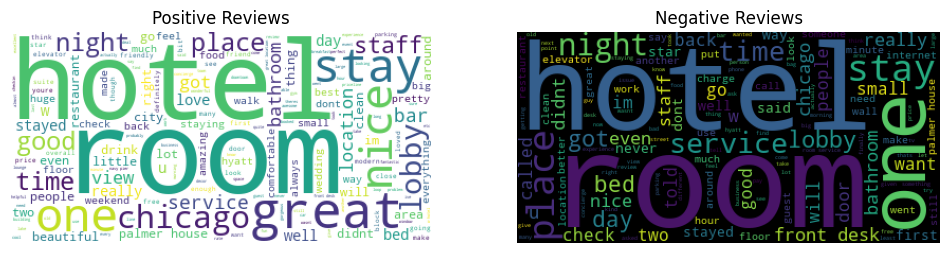


Top Positive Bigrams:
                   term  freq
17428      palmer house   112
16057         navy pier    54
10143    great location    44
20795      room service    35
26514  walking distance    34
24394          th floor    32
19638       really nice    28
14111         lobby bar    27
12680        ive stayed    27
10134       great hotel    25

Top Negative Bigrams:
                   term  freq
9329       palmer house    39
11177      room service    27
2944   customer service    20
6151         hotel room    14
13239          th floor    14
11186        room small    13
3713          dont know    12
4574          felt like    12
12678        stay hotel    11
11319       rooms small    11


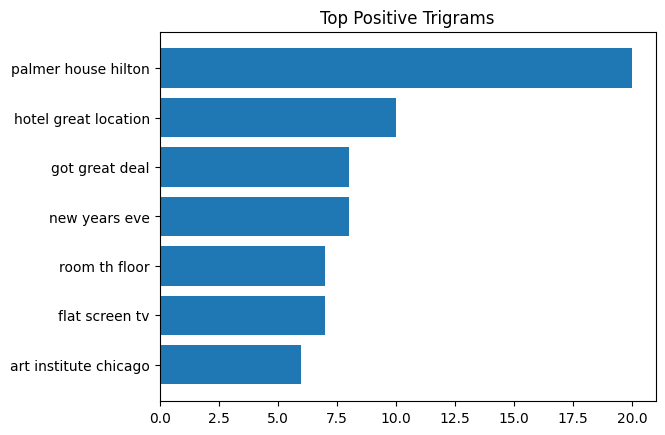


Model Results (CountVectorizer):
  Model  Accuracy        F1
0    LR  0.731579  0.751220
1    NB  0.773684  0.796209
2   SGD  0.747368  0.757576

Model Results (TF-IDF):
  Model  Accuracy        F1
0    LR  0.747368  0.787611
1    NB  0.621053  0.731343
2   SGD  0.752632  0.763819


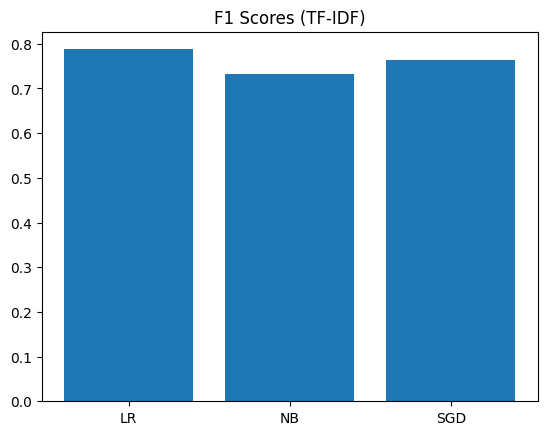


Example Prediction:
Great service, beautiful hotel and rooms! The lobby felt like a nightclub! Very hip!
Positive


In [31]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import re
import requests
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from wordcloud import WordCloud

import spacy

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score

# ================================
# 2. LOAD HOTEL DATA
# ================================
df = pd.read_csv("hotel_final.csv")

# ================================
# 3. BASIC CLEANING
# ================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df["text"] = df["reviewContent"].apply(clean_text)

# ================================
# 4. WEB SCRAPING + MERGE INTO ONE DOC
# ================================
url = "https://en.wikipedia.org/wiki/Hotel"
response = requests.get(url)

soup = BeautifulSoup(response.text, "lxml")

wiki_p = [p.text for p in soup.find_all("p")]

wiki_df = pd.DataFrame({"text": wiki_p})

print("Before merge:")
print(wiki_df.head())

wiki_df = pd.DataFrame({"text": " ".join(wiki_df["text"])}, index=[0])

print("After merge:")
print(wiki_df)

# ================================
# 5. NER WITH SPACY
# ================================
nlp = spacy.load("en_core_web_sm")

doc = nlp(wiki_df.loc[0, "text"])

entities = [(ent.text, ent.label_) for ent in doc.ents]
ner_df = pd.DataFrame(entities, columns=["Entity", "Label"])

print("\nNER Results:")
print(ner_df.head())

# Top People
top_people = ner_df[ner_df["Label"] == "PERSON"]["Entity"].value_counts().head(10)
print("\nTop People:")
print(top_people)

# Top Orgs
top_orgs = ner_df[ner_df["Label"] == "ORG"]["Entity"].value_counts().head(10)
print("\nTop Orgs:")
print(top_orgs)

# ================================
# 6. SENTIMENT SPLIT (BASED ON RATING)
# ================================
positive_reviews = df[df["rating"] >= 4]
negative_reviews = df[df["rating"] <= 2]

print("\nReview Distribution:")
print("Total:", len(df))
print("Positive %:", len(positive_reviews)/len(df)*100)
print("Negative %:", len(negative_reviews)/len(df)*100)

# ================================
# 7. WORD CLOUDS
# ================================
pos_text = " ".join(positive_reviews["text"])
neg_text = " ".join(negative_reviews["text"])

pos_wc = WordCloud(background_color="white").generate(pos_text)
neg_wc = WordCloud(background_color="black").generate(neg_text)

fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].imshow(pos_wc)
axes[0].set_title("Positive Reviews")
axes[0].axis("off")

axes[1].imshow(neg_wc)
axes[1].set_title("Negative Reviews")
axes[1].axis("off")

plt.show()

# ================================
# 8. N-GRAM FUNCTION
# ================================
def get_top_ngrams(text_series, ngram_range=(1,1), top_n=10):
    combined = " ".join(text_series)
    v = CountVectorizer(stop_words="english", ngram_range=ngram_range)
    X = v.fit_transform([combined])
    
    df_ngram = pd.DataFrame({
        "term": v.get_feature_names_out(),
        "freq": X.toarray()[0]
    })
    
    return df_ngram.sort_values(by="freq", ascending=False).head(top_n)

# Top Bigrams
print("\nTop Positive Bigrams:")
print(get_top_ngrams(positive_reviews["text"], (2,2)))

print("\nTop Negative Bigrams:")
print(get_top_ngrams(negative_reviews["text"], (2,2)))

# ================================
# 9. PLOT N-GRAMS
# ================================
def plot_ngrams(text_series, ngram_range=(1,1), top_n=10, title="Top Terms"):
    df_ng = get_top_ngrams(text_series, ngram_range, top_n)
    df_ng = df_ng.sort_values(by="freq")

    plt.barh(df_ng["term"], df_ng["freq"])
    plt.title(title)
    plt.show()

plot_ngrams(positive_reviews["text"], (3,3), 7, "Top Positive Trigrams")

# ================================
# 10. SENTIMENT MODELING
# ================================
df["pos_rev"] = np.where(df["rating"] >= 4, 1, 0)

X = df["text"]
y = df["pos_rev"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Count Vectorizer
cv = CountVectorizer(stop_words="english")
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

# Models
lr = LogisticRegression(max_iter=1000)
nb = MultinomialNB()
sgd = SGDClassifier()

models = {"LR": lr, "NB": nb, "SGD": sgd}

results = []

for name, model in models.items():
    model.fit(X_train_cv, y_train)
    preds = model.predict(X_test_cv)
    results.append([
        name,
        accuracy_score(y_test, preds),
        f1_score(y_test, preds)
    ])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1"])
print("\nModel Results (CountVectorizer):")
print(results_df)

# ================================
# 11. TF-IDF VERSION
# ================================
tfidf = TfidfVectorizer(stop_words="english")

X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)

results = []

for name, model in models.items():
    model.fit(X_train_tf, y_train)
    preds = model.predict(X_test_tf)
    results.append([
        name,
        accuracy_score(y_test, preds),
        f1_score(y_test, preds)
    ])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1"])
print("\nModel Results (TF-IDF):")
print(results_df)

# ================================
# 12. PLOT MODEL PERFORMANCE
# ================================
plt.bar(results_df["Model"], results_df["F1"])
plt.title("F1 Scores (TF-IDF)")
plt.show()

# ================================
# 13. TEXT CLASSIFICATION FUNCTION
# ================================
def textclass_pred(text):
    vec = tfidf.transform([text])
    pred = lr.predict(vec)[0]
    return "Positive" if pred == 1 else "Negative"

# Test
print("\nExample Prediction:")
print(df["reviewContent"].iloc[5])
print(textclass_pred(df["reviewContent"].iloc[5]))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rick\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Rick\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Dataset Shape: (949, 6)

Sentiment Distribution:
sentiment
positive    828
negative    115
neutral       6
Name: count, dtype: int64

Q1: WHAT TOPICS DO REVIEWERS BRING UP?

Topic 0:
hotel, room, great, chicago, nice, location, stay, lobby, good, service

Topic 1:
hotel, room, know, got, people, guy, service, dont, staff, bags

Topic 2:
hotel, room, great, stay, chicago, rooms, hyatt, parking, night, day

Topic 3:
room, hotel, like, night, service, place, stay, nice, time, rooms

Topic 4:
rooms, hotel, room, lobby, nice, great, place, bar, location, chicago

Q2: HOW DO HAPPY VS UNHAPPY CUSTOMERS DIFFER?
sentiment       negative  neutral  positive
dominant_topic                             
0                     14        3       204
1                     13        0        18
2                     12        1       164
3                     71        1       314
4                      5        1       128


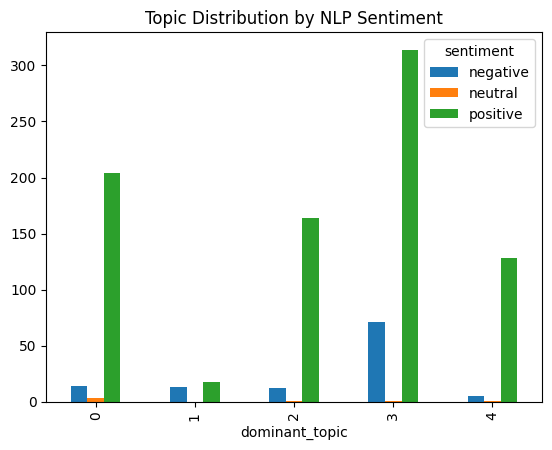


Q3: OTHER CUSTOMER CHARACTERISTICS

Average Review Length:
sentiment
negative    69.495652
neutral     28.333333
positive    69.417874
Name: review_length, dtype: float64

Engagement Metrics:
           usefulCount  coolCount  funnyCount
sentiment                                    
negative      0.678261   0.191304    0.278261
neutral       0.166667   0.166667    0.166667
positive      0.932367   0.514493    0.393720

Q4: WHAT SHOULD THE HOTEL FOCUS ON?
       word  count
78     room    207
44    hotel    201
83  service     70
64    night     63
79    rooms     51
87     stay     49
54     like     47
41      got     47
22     desk     46
85    staff     44
56    lobby     41
72    place     39
94     time     38
6       bed     38
25     dont     37

Q5: MAIN TAKEAWAYS & RECOMMENDATIONS

- Focus on improving service quality and staff responsiveness
- Address cleanliness and maintenance issues
- Reduce wait times and operational delays
- Maintain strengths in location and amenities


In [33]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('stopwords')
nltk.download('vader_lexicon')

# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("hotel_final.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Dataset Shape:", df.shape)

# ================================
# 3. CLEAN TEXT
# ================================
# ✅ FIX: convert stopwords to LIST
base_stopwords = list(set(stopwords.words('english')).union(ENGLISH_STOP_WORDS))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in base_stopwords and len(w) > 2]
    return " ".join(words)

df["clean_text"] = df["reviewContent"].apply(clean_text)

# ================================
# 4. SENTIMENT ANALYSIS (VADER)
# ================================
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["reviewContent"].apply(get_sentiment)

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

# ================================
# 5. TOPIC MODELING (LDA)
# ================================
vectorizer = CountVectorizer(
    stop_words=base_stopwords,   # ✅ now valid
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9
)

X = vectorizer.fit_transform(df["clean_text"])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

feature_names = vectorizer.get_feature_names_out()

def display_topics(model, feature_names, n_words=10):
    topic_dict = {}
    for i, topic in enumerate(model.components_):
        words = [feature_names[j] for j in topic.argsort()[-n_words:]][::-1]
        topic_dict[i] = words
    return topic_dict

topics = display_topics(lda, feature_names)

# ================================
# Q1: TOPICS
# ================================
print("\n==============================")
print("Q1: WHAT TOPICS DO REVIEWERS BRING UP?")
print("==============================")

for k, v in topics.items():
    print(f"\nTopic {k}:")
    print(", ".join(v))

# Assign dominant topic
topic_values = lda.transform(X)
df["dominant_topic"] = topic_values.argmax(axis=1)

# ================================
# Q2: SENTIMENT DIFFERENCES
# ================================
print("\n==============================")
print("Q2: HOW DO HAPPY VS UNHAPPY CUSTOMERS DIFFER?")
print("==============================")

comparison = pd.crosstab(df["dominant_topic"], df["sentiment"])
print(comparison)

comparison.plot(kind="bar")
plt.title("Topic Distribution by NLP Sentiment")
plt.show()

# ================================
# Q3: OTHER CHARACTERISTICS
# ================================
print("\n==============================")
print("Q3: OTHER CUSTOMER CHARACTERISTICS")
print("==============================")

df["review_length"] = df["clean_text"].apply(lambda x: len(x.split()))

print("\nAverage Review Length:")
print(df.groupby("sentiment")["review_length"].mean())

print("\nEngagement Metrics:")
print(df.groupby("sentiment")[["usefulCount","coolCount","funnyCount"]].mean())

# ================================
# Q4: WHAT TO FIX
# ================================
print("\n==============================")
print("Q4: WHAT SHOULD THE HOTEL FOCUS ON?")
print("==============================")

neg_df = df[df["sentiment"] == "negative"]

neg_vectorizer = CountVectorizer(
    stop_words=base_stopwords,
    min_df=10,
    max_df=0.9
)

X_neg = neg_vectorizer.fit_transform(neg_df["clean_text"])

word_counts = np.asarray(X_neg.sum(axis=0)).flatten()
words = neg_vectorizer.get_feature_names_out()

neg_words = pd.DataFrame({
    "word": words,
    "count": word_counts
}).sort_values(by="count", ascending=False)

print(neg_words.head(15))

# ================================
# Q5: RECOMMENDATIONS
# ================================
print("\n==============================")
print("Q5: MAIN TAKEAWAYS & RECOMMENDATIONS")
print("==============================")

print("""
- Focus on improving service quality and staff responsiveness
- Address cleanliness and maintenance issues
- Reduce wait times and operational delays
- Maintain strengths in location and amenities
""")

# ================================
# SAVE
# ================================
df.to_csv("final_fixed_output.csv", index=False)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rick\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Rick\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Dataset Shape: (949, 6)

Sentiment Distribution:
sentiment
positive    828
negative    115
neutral       6
Name: count, dtype: int64

Q1: WHAT TOPICS DO REVIEWERS BRING UP?

Topic 0 → Service & Staff Experience
Keywords: hotel, room, great, chicago, nice, location, stay, lobby, good, service

Topic 1 → Service & Staff Experience
Keywords: hotel, room, know, got, people, guy, service, dont, staff, bags

Topic 2 → General Customer Experience
Keywords: hotel, room, great, stay, chicago, rooms, hyatt, parking, night, day

Topic 3 → Service & Staff Experience
Keywords: room, hotel, like, night, service, place, stay, nice, time, rooms

Topic 4 → Location & Accessibility
Keywords: rooms, hotel, room, lobby, nice, great, place, bar, location, chicago

Q2: HOW DO HAPPY VS UNHAPPY CUSTOMERS DIFFER?

Topic vs Sentiment:
sentiment                    negative  neutral  positive
topic_label                                             
General Customer Experience        12        1       164
Location

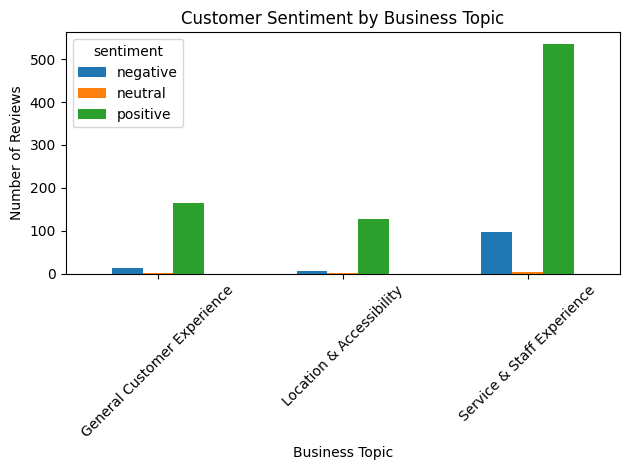


Q3: OTHER CUSTOMER CHARACTERISTICS

Average Review Length:
sentiment
negative    69.495652
neutral     28.333333
positive    69.417874
Name: review_length, dtype: float64

Engagement Metrics:
           usefulCount  coolCount  funnyCount
sentiment                                    
negative      0.678261   0.191304    0.278261
neutral       0.166667   0.166667    0.166667
positive      0.932367   0.514493    0.393720

Q4: WHAT SHOULD THE HOTEL FOCUS ON?

Top Issues in Negative Reviews:
       word  count
78     room    207
44    hotel    201
83  service     70
64    night     63
79    rooms     51
87     stay     49
54     like     47
41      got     47
22     desk     46
85    staff     44
56    lobby     41
72    place     39
94     time     38
6       bed     38
25     dont     37

Q5: MAIN TAKEAWAYS & RECOMMENDATIONS

KEY INSIGHTS:

• Customers mainly discuss:
  - Service quality
  - Room cleanliness
  - Location convenience
  - Amenities and facilities

• Negative sentiment is s

In [34]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('stopwords')
nltk.download('vader_lexicon')

# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("hotel_final.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Dataset Shape:", df.shape)

# ================================
# 3. CLEAN TEXT
# ================================
base_stopwords = list(set(stopwords.words('english')).union(ENGLISH_STOP_WORDS))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in base_stopwords and len(w) > 2]
    return " ".join(words)

df["clean_text"] = df["reviewContent"].apply(clean_text)

# ================================
# 4. SENTIMENT ANALYSIS (VADER)
# ================================
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["reviewContent"].apply(get_sentiment)

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

# ================================
# 5. TOPIC MODELING (LDA)
# ================================
vectorizer = CountVectorizer(
    stop_words=base_stopwords,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9
)

X = vectorizer.fit_transform(df["clean_text"])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

feature_names = vectorizer.get_feature_names_out()

def display_topics(model, feature_names, n_words=10):
    topic_dict = {}
    for i, topic in enumerate(model.components_):
        words = [feature_names[j] for j in topic.argsort()[-n_words:]][::-1]
        topic_dict[i] = words
    return topic_dict

topics = display_topics(lda, feature_names)

# ================================
# 6. BUSINESS TOPIC LABELING
# ================================
def label_topic(words):
    text = " ".join(words).lower()

    if any(x in text for x in ["staff", "service", "desk", "check", "told"]):
        return "Service & Staff Experience"

    elif any(x in text for x in ["clean", "bathroom", "dirty", "bed", "floor"]):
        return "Room Cleanliness & Comfort"

    elif any(x in text for x in ["location", "downtown", "walk", "distance", "avenue"]):
        return "Location & Accessibility"

    elif any(x in text for x in ["wifi", "internet", "coffee", "bar", "lobby"]):
        return "Amenities & Facilities"

    elif any(x in text for x in ["view", "lake", "beautiful", "experience"]):
        return "Overall Experience & Atmosphere"

    else:
        return "General Customer Experience"

# Apply labels to topics
labeled_topics = {}

print("\n==============================")
print("Q1: WHAT TOPICS DO REVIEWERS BRING UP?")
print("==============================")

for k, v in topics.items():
    label = label_topic(v)
    labeled_topics[k] = label

    print(f"\nTopic {k} → {label}")
    print("Keywords:", ", ".join(v))

# Assign dominant topic
topic_values = lda.transform(X)
df["dominant_topic"] = topic_values.argmax(axis=1)

# Map to business labels
df["topic_label"] = df["dominant_topic"].map(labeled_topics)

# ================================
# Q2: SENTIMENT DIFFERENCES
# ================================
print("\n==============================")
print("Q2: HOW DO HAPPY VS UNHAPPY CUSTOMERS DIFFER?")
print("==============================")

comparison = pd.crosstab(df["topic_label"], df["sentiment"])
print("\nTopic vs Sentiment:")
print(comparison)

comparison.plot(kind="bar")
plt.title("Customer Sentiment by Business Topic")
plt.xlabel("Business Topic")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ================================
# Q3: OTHER CUSTOMER CHARACTERISTICS
# ================================
print("\n==============================")
print("Q3: OTHER CUSTOMER CHARACTERISTICS")
print("==============================")

df["review_length"] = df["clean_text"].apply(lambda x: len(x.split()))

print("\nAverage Review Length:")
print(df.groupby("sentiment")["review_length"].mean())

print("\nEngagement Metrics:")
print(df.groupby("sentiment")[["usefulCount","coolCount","funnyCount"]].mean())

# ================================
# Q4: WHAT SHOULD THE HOTEL FOCUS ON?
# ================================
print("\n==============================")
print("Q4: WHAT SHOULD THE HOTEL FOCUS ON?")
print("==============================")

neg_df = df[df["sentiment"] == "negative"]

neg_vectorizer = CountVectorizer(
    stop_words=base_stopwords,
    min_df=10,
    max_df=0.9
)

X_neg = neg_vectorizer.fit_transform(neg_df["clean_text"])

word_counts = np.asarray(X_neg.sum(axis=0)).flatten()
words = neg_vectorizer.get_feature_names_out()

neg_words = pd.DataFrame({
    "word": words,
    "count": word_counts
}).sort_values(by="count", ascending=False)

print("\nTop Issues in Negative Reviews:")
print(neg_words.head(15))

# ================================
# Q5: MAIN TAKEAWAYS & RECOMMENDATIONS
# ================================
print("\n==============================")
print("Q5: MAIN TAKEAWAYS & RECOMMENDATIONS")
print("==============================")

print("""
KEY INSIGHTS:

• Customers mainly discuss:
  - Service quality
  - Room cleanliness
  - Location convenience
  - Amenities and facilities

• Negative sentiment is strongly driven by:
  - Poor staff/service interactions
  - Cleanliness and maintenance issues
  - Delays and inefficiencies

• Positive sentiment is driven by:
  - Location and accessibility
  - Comfortable rooms
  - Friendly staff

RECOMMENDATIONS:

1. PRIORITIZE SERVICE QUALITY
   - Train staff for consistency and responsiveness

2. IMPROVE CLEANLINESS & MAINTENANCE
   - Focus on bathrooms, beds, and room condition

3. REDUCE CUSTOMER FRICTION
   - Improve check-in/check-out speed

4. LEVERAGE STRENGTHS
   - Highlight location and amenities in marketing

""")

# ================================
# SAVE OUTPUT
# ================================
df.to_csv("final_business_topic_output.csv", index=False)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rick\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 24971.87it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 30/30 [00:05<00:00,  5.19it/s]
2026-04-23 20:35:17,074 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-23 20:35:18,030 - BERTopic - Dimensionality - Completed ✓
2026-04-23 20:35:18,031 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-23 20:35:18,064 - BERTopic - Cluster - Completed ✓
2026-04-23 20:35:18,065 - BERTopic - Representation - Extracting topics using c-TF-I


=== BERTopic Topics ===

Topic 0 → Scenic Experience & Staff Interaction
[('lobby', np.float64(0.082324550728702)), ('bar', np.float64(0.07803015037516607)), ('get', np.float64(0.07766131712105799)), ('one', np.float64(0.07007256707576578)), ('location', np.float64(0.07003828357459727)), ('would', np.float64(0.06428248715301388)), ('time', np.float64(0.06260171017366101)), ('service', np.float64(0.06108370779975377)), ('staff', np.float64(0.05738828018964042)), ('hotels', np.float64(0.0569468980903089))]

Topic 1 → Business Hotel Comfort & Amenities
[('would', np.float64(0.09911464687519207)), ('get', np.float64(0.0801378867263586)), ('one', np.float64(0.07716301646518683)), ('service', np.float64(0.07495267570436974)), ('bed', np.float64(0.07349061321069314)), ('didnt', np.float64(0.06547923042582879)), ('back', np.float64(0.06514715394714549)), ('time', np.float64(0.06042093407218462)), ('could', np.float64(0.058400394704117564)), ('floor', np.float64(0.05764398797648743))]

Topic 2

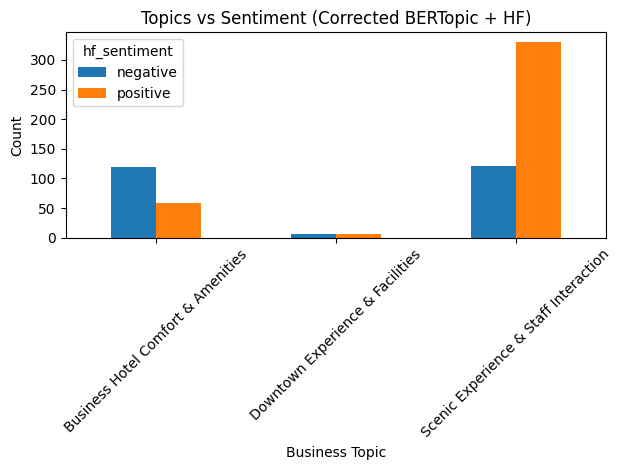


Review Length by Sentiment:
hf_sentiment
negative    74.553134
positive    59.975945
Name: review_length, dtype: float64

Engagement by Sentiment:
              usefulCount  coolCount  funnyCount
hf_sentiment                                    
negative         0.937330   0.367847    0.455041
positive         0.871134   0.539519    0.329897

Top Negative Words:
          word  count
671        one    480
394        get    467
1103     would    435
166    chicago    430
548      lobby    428
839    service    406
550   location    345
979       time    332
904      staff    303
25        also    290
68         bar    281
412        got    279
1039      view    271
81         bed    268
367      floor    239


In [37]:
# ================================
# 1. IMPORTS
# ================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from transformers import pipeline

# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("hotel_final.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# ================================
# 3. STOPWORDS
# ================================
base_stopwords = set(stopwords.words('english'))

generic_words = {
    "good","great","nice","amazing","awesome","excellent",
    "bad","okay","ok","fine","perfect","love","like",
    "really","very","pretty","much","lot","little"
}

domain_words = {
    "hotel","room","rooms","stay","stayed","night","nights",
    "place","property","trip","visit"
}

all_stopwords = list(base_stopwords.union(generic_words).union(domain_words))

# ================================
# 4. CLEAN TEXT
# ================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in all_stopwords and len(w) > 2]
    return " ".join(words)

df["clean_text"] = df["reviewContent"].apply(clean_text)

# ================================
# 5. SAFE TRUNCATION (CRITICAL FIX)
# ================================
def truncate(text, max_words=180):
    return " ".join(str(text).split()[:max_words])

df["clean_text_trunc"] = df["clean_text"].apply(truncate)
docs = df["clean_text_trunc"].tolist()

# ================================
# 6. EMBEDDINGS
# ================================
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embedding_model.encode(
    docs,
    show_progress_bar=True,
    convert_to_numpy=True
)

# ================================
# 7. VECTOR MODEL
# ================================
vectorizer_model = CountVectorizer(
    stop_words=all_stopwords,
    ngram_range=(1,2),
    min_df=5
)

# ================================
# 8. BERTopic MODEL
# ================================
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    nr_topics=5,
    calculate_probabilities=False,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

df["topic_id"] = topics

# ================================
# 9. SENTIMENT (FIXED + SAFE BATCHING)
# ================================
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

def get_sentiment_batch(texts, batch_size=32):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = [truncate(t) for t in texts[i:i+batch_size]]
        preds = sentiment_model(batch)
        results.extend([p["label"].lower() for p in preds])
    return results

df["hf_sentiment"] = get_sentiment_batch(df["reviewContent"].tolist())

# ================================
# 10. BUSINESS LABELING (FIXED)
# ================================
def assign_standard_label(text):
    t = text.lower()

    if any(x in t for x in ["lake", "view", "spa", "staff"]):
        return "Scenic Experience & Staff Interaction"

    elif any(x in t for x in ["hyatt", "regency", "bed", "coffee", "internet"]):
        return "Business Hotel Comfort & Amenities"

    elif any(x in t for x in ["navy pier", "millennium", "michigan", "walking"]):
        return "Tourist Location & Accessibility"

    elif any(x in t for x in ["downtown", "lobby", "wifi", "bar"]):
        return "Downtown Experience & Facilities"

    elif any(x in t for x in ["palmer", "art institute", "historic"]):
        return "Landmark Hotel & Cultural Experience"

    else:
        return "General Experience Theme"

# 🔥 FIX: map from BERTopic, NOT raw text
topic_labels = {}

for topic_id in set(topics):
    if topic_id != -1:
        words = [word for word, _ in topic_model.get_topic(topic_id)]
        topic_labels[topic_id] = assign_standard_label(" ".join(words))

df["topic_label"] = df["topic_id"].map(topic_labels)

# ================================
# 11. INSPECT TOPICS
# ================================
print("\n=== BERTopic Topics ===")
for t in set(topics):
    if t != -1:
        print(f"\nTopic {t} → {topic_labels.get(t)}")
        print(topic_model.get_topic(t))

# ================================
# 12. TOPIC VS SENTIMENT PLOT
# ================================
plot_data = pd.crosstab(
    df["topic_label"],
    df["hf_sentiment"]
)

plot_data.plot(kind="bar")

plt.title("Topics vs Sentiment (Corrected BERTopic + HF)")
plt.xlabel("Business Topic")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ================================
# 13. REVIEW LENGTH
# ================================
df["review_length"] = df["clean_text_trunc"].apply(lambda x: len(x.split()))

print("\nReview Length by Sentiment:")
print(df.groupby("hf_sentiment")["review_length"].mean())

# ================================
# 14. ENGAGEMENT
# ================================
print("\nEngagement by Sentiment:")
print(
    df.groupby("hf_sentiment")[
        ["usefulCount", "coolCount", "funnyCount"]
    ].mean()
)

# ================================
# 15. NEGATIVE WORDS
# ================================
neg_df = df[df["hf_sentiment"] == "negative"]

neg_vec = CountVectorizer(
    stop_words=all_stopwords,
    min_df=10,
    max_df=0.9
)

X_neg = neg_vec.fit_transform(df["clean_text_trunc"])

word_counts = np.asarray(X_neg.sum(axis=0)).flatten()
words = neg_vec.get_feature_names_out()

top_words = pd.DataFrame({
    "word": words,
    "count": word_counts
}).sort_values(by="count", ascending=False)

print("\nTop Negative Words:")
print(top_words.head(15))

# ================================
# 16. SAVE OUTPUT
# ================================
df.to_csv("final_hf_bertopic_fixed.csv", index=False)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rick\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12005.37it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 30/30 [00:05<00:00,  5.33it/s]
2026-04-23 20:38:11,696 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-23 20:38:12,424 - BERTopic - Dimensionality - Completed ✓
2026-04-23 20:38:12,425 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-23 20:38:12,462 - BERTopic - Cluster - Completed ✓
2026-04-23 20:38:12,463 - BERTopic - Representation - Extracting topics using c-TF-I

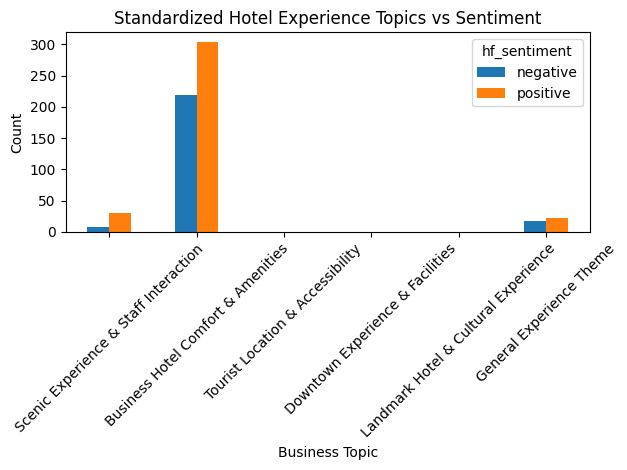

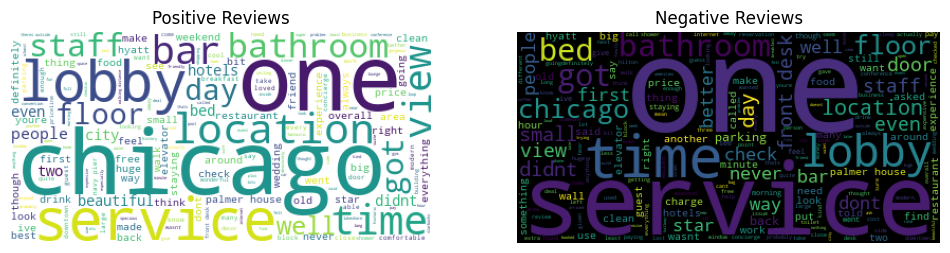


TOP POSITIVE N-GRAMS:
                   term  freq
18575      palmer house   102
17199         navy pier    57
10921        front desk    50
27706  walking distance    35
13390     hyatt regency    33
16604      michigan ave    28
27397         view lake    27
23916    staff friendly    25
16724   millennium park    24
14392     lake michigan    24

BOTTOM POSITIVE N-GRAMS:
                   term  freq
1504          ass price     1
37         abound stars     1
38         aboutdun dun     1
39      absolut vanilla     1
1505       assembly hoc     1
41         absolute mad     1
42    absolute stunning     1
1506     asset bathroom     1
1507     assist arrival     1
11         able explore     1

TOP NEGATIVE N-GRAMS:
               term  freq
8773     front desk    94
15393  palmer house    69
14163     navy pier    25
14440     next door    18
4993     could hear    17
14460     next time    16
8659      free wifi    15
22833    walls thin    13
7203    even though    13
4320    

KeyError: 'Column not found: review_length'

In [38]:
# ================================
# 1. IMPORTS
# ================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from transformers import pipeline

# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("hotel_final.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# ================================
# 3. STOPWORDS
# ================================
base_stopwords = set(stopwords.words('english'))

generic_words = {
    "good","great","nice","amazing","awesome","excellent",
    "bad","okay","ok","fine","perfect","love","like",
    "really","very","pretty","much","lot","little"
}

domain_words = {
    "hotel","room","rooms","stay","stayed","night","nights",
    "place","property","trip","visit"
}

all_stopwords = list(base_stopwords.union(generic_words).union(domain_words))

# ================================
# 4. CLEAN TEXT
# ================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in all_stopwords and len(w) > 2]
    return " ".join(words)

df["clean_text"] = df["reviewContent"].apply(clean_text)

# ================================
# 5. TRUNCATION (CONSISTENCY FIX)
# ================================
def truncate(text, max_words=180):
    return " ".join(str(text).split()[:max_words])

df["clean_text_trunc"] = df["clean_text"].apply(truncate)
docs = df["clean_text_trunc"].tolist()

# ================================
# 6. EMBEDDINGS
# ================================
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embedding_model.encode(
    docs,
    show_progress_bar=True,
    convert_to_numpy=True
)

# ================================
# 7. VECTOR MODEL
# ================================
vectorizer_model = CountVectorizer(
    stop_words=all_stopwords,
    ngram_range=(1,2),
    min_df=5
)

# ================================
# 8. BERTopic
# ================================
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    nr_topics=5,
    calculate_probabilities=False,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

df["topic_id"] = topics

# ================================
# 9. SENTIMENT (BATCHED HF)
# ================================
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

def get_sentiment_batch(texts, batch_size=32):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = [truncate(t) for t in texts[i:i+batch_size]]
        preds = sentiment_model(batch)
        results.extend([p["label"].lower() for p in preds])
    return results

df["hf_sentiment"] = get_sentiment_batch(df["reviewContent"].tolist())

# ================================
# 10. STANDARD BUSINESS LABELS
# ================================
STANDARD_LABELS = [
    "Scenic Experience & Staff Interaction",
    "Business Hotel Comfort & Amenities",
    "Tourist Location & Accessibility",
    "Downtown Experience & Facilities",
    "Landmark Hotel & Cultural Experience",
    "General Experience Theme"
]

def assign_standard_label(text):
    t = text.lower()

    if any(x in t for x in ["lake", "view", "spa", "staff"]):
        return "Scenic Experience & Staff Interaction"

    elif any(x in t for x in ["hyatt", "regency", "bed", "coffee", "internet"]):
        return "Business Hotel Comfort & Amenities"

    elif any(x in t for x in ["navy pier", "millennium", "michigan", "walking"]):
        return "Tourist Location & Accessibility"

    elif any(x in t for x in ["downtown", "lobby", "wifi", "bar"]):
        return "Downtown Experience & Facilities"

    elif any(x in t for x in ["palmer", "art institute", "historic"]):
        return "Landmark Hotel & Cultural Experience"

    else:
        return "General Experience Theme"

# Map BERTopic → labels
topic_labels = {}

for topic_id in set(topics):
    if topic_id != -1:
        words = [w for w, _ in topic_model.get_topic(topic_id)]
        topic_labels[topic_id] = assign_standard_label(" ".join(words))

df["topic_label"] = df["topic_id"].map(topic_labels)

# ================================
# 11. PLOT ALL STANDARD LABELS (FIXED FULL DISPLAY)
# ================================
plot_data = pd.crosstab(
    df["topic_label"],
    df["hf_sentiment"]
)

# force ALL labels to appear
plot_data = plot_data.reindex(STANDARD_LABELS, fill_value=0)

plot_data.plot(kind="bar")

plt.title("Standardized Hotel Experience Topics vs Sentiment")
plt.xlabel("Business Topic")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ================================
# 12. WORDCLOUDS (POSITIVE vs NEGATIVE)
# ================================
positive_text = " ".join(df[df["hf_sentiment"] == "positive"]["clean_text_trunc"])
negative_text = " ".join(df[df["hf_sentiment"] == "negative"]["clean_text_trunc"])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(WordCloud(background_color="white").generate(positive_text))
plt.title("Positive Reviews")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(WordCloud(background_color="black").generate(negative_text))
plt.title("Negative Reviews")
plt.axis("off")

plt.show()

# ================================
# 13. TOP & BOTTOM N-GRAMS
# ================================
def get_ngrams(text, ngram_range, top_n=10):
    vec = CountVectorizer(stop_words=all_stopwords, ngram_range=ngram_range)
    dtm = vec.fit_transform([text])
    df_ng = pd.DataFrame({
        "term": vec.get_feature_names_out(),
        "freq": np.asarray(dtm.sum(axis=0)).flatten()
    }).sort_values(by="freq", ascending=False)
    return df_ng.head(top_n), df_ng.tail(top_n)

# POSITIVE
pos_text = " ".join(df[df["hf_sentiment"] == "positive"]["clean_text_trunc"])
top_pos, bottom_pos = get_ngrams(pos_text, (2,2))

# NEGATIVE
neg_text = " ".join(df[df["hf_sentiment"] == "negative"]["clean_text_trunc"])
top_neg, bottom_neg = get_ngrams(neg_text, (2,2))

print("\nTOP POSITIVE N-GRAMS:")
print(top_pos)

print("\nBOTTOM POSITIVE N-GRAMS:")
print(bottom_pos)

print("\nTOP NEGATIVE N-GRAMS:")
print(top_neg)

print("\nBOTTOM NEGATIVE N-GRAMS:")
print(bottom_neg)

# ================================
# 14. REVIEW LENGTH
# ================================
print("\nReview Length by Sentiment:")
print(df.groupby("hf_sentiment")["review_length"].mean())

# ================================
# 15. ENGAGEMENT
# ================================
print("\nEngagement by Sentiment:")
print(df.groupby("hf_sentiment")[["usefulCount","coolCount","funnyCount"]].mean())

# ================================
# 16. SAVE OUTPUT
# ================================
df.to_csv("final_full_analysis_output.csv", index=False)